### 馬達論文研究
### 第五步 隨機抽樣進行檢測
### 馬達B 6000RPM
### 使用CNN_VGG

In [15]:
import os
import random
import warnings
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter, defaultdict

import hdbscan
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Model, load_model
from gpu_utils import device_scope

warnings.filterwarnings("ignore")

In [16]:
# --------------------------- 全域參數 ---------------------------
ROOT_DIR = os.getcwd()
FEATURE_DIR = os.path.join(ROOT_DIR, "階段2", "myfeature")
MODEL_PATH = os.path.join(ROOT_DIR, "階段2", "model", "VGG16_B6000_1.keras")
RPM = "6000rpm"            # 目前只跑 B 6000 RPM，可自行改
T_CODE = "T2"              # 資料夾代號 (時間點)
LABEL_ORDER = [
    "8screws",
    "1screws",
    "2screws",
    "3screws",
    "4screws",
]  # 舊資料標籤順序

In [17]:
# ➜ 想一次測多種設定就寫在這裡
MIN_CLUSTER_SIZES = [25]  # 最小群集大小
CONF_LEVELS = [0.95]
UNKNOWN_BATCHES = [
    ["5screws"],
    ["5screws", "6screws"],
    ["5screws", "6screws", "7screws"],
    ["5screws", "6screws", "7screws", "3_14screws"],
    ["5screws", "6screws", "7screws", "3_14screws", "4_146screws"],
]

LABEL_ORDER = ["8screws", "1screws", "2screws", "3screws", "4screws"]

NAME_MAP = {          # ★ 新增
    "8screws": "Healthy",
    "1screws": "Faulty 1",
    "2screws": "Faulty 2",
    "3screws": "Faulty 3",
    "4screws": "Faulty 4",
}

PER_SCREW_LIMIT   = 60
MAX_COMBO_SAMPLE  = 450      

In [18]:
# --- 只抽一組 UNKNOWN_BATCH ---
ALL_UNKNOWN_SCREWS = ["5screws", "6screws", "7screws", "3_14screws", "4_146screws"]
MAX_SCREWS_PER_BATCH = 5

# 對應標籤轉換表
UNKNOWN_LABEL_MAP = {
    "5screws": "Unknown 1",
    "6screws": "Unknown 2",
    "7screws": "Unknown 3",
    "4_146screws": "Unknown 4",
    "3_14screws": "Unknown 5"
}

k = random.randint(1, min(len(ALL_UNKNOWN_SCREWS), MAX_SCREWS_PER_BATCH))
batch = random.sample(ALL_UNKNOWN_SCREWS, k)
UNKNOWN_BATCHES = [batch]

# 顯示對應的標籤
translated = [UNKNOWN_LABEL_MAP.get(s, s) for s in batch]

print("\n本次隨機抽取組合：")
print(translated)


本次隨機抽取組合：
['Unknown 1', 'Unknown 5', 'Unknown 4', 'Unknown 3', 'Unknown 2']


In [19]:
def get_colors(k):
    """回傳長度 k 的顏色 list：前 5 固定紅橙黃綠藍，其餘由 extra_colors 指定"""
    base = ["red", "orange", "yellow", "green", "blue"]
    if k <= 5:
        return base[:k]
    else:
        # 自行指定剩下要用的顏色（長度至少要 >= k-5）
        extra_colors = [
            "cyan", "purple", "magenta", "pink", "brown"
            # … 如果 k-5 > 10，就再補更多顏色或重複利用
        ]
        needed = k - 5
        if needed > len(extra_colors):
            # 若指定顏色不夠，就循環取用
            extra = [extra_colors[i % len(extra_colors)] for i in range(needed)]
        else:
            extra = extra_colors[:needed]

        return base + extra

In [20]:
def plot_centroids_together(center_list, thr):
    """中心距離總覽水平 bar"""
    k = len(center_list)
    if k == 0:
        return
    center_list.sort(key=lambda x: x[1])             # 依距離排序
    x_vals  = [c[1] for c in center_list]
    labels  = [c[0] for c in center_list]
    colors  = get_colors(k)

    plt.figure(figsize=(6, 0.6*k + 2))
    plt.barh(np.arange(k), x_vals, color=colors, edgecolor="k", height=0.6)
    plt.axvline(thr, color="r", ls="--", lw=1.5, label=f"thr={thr:.2f}")
    plt.yticks(np.arange(k), labels)
    plt.xlabel("Mahalanobis distance")
    plt.title(f"HDBSCAN_cluster = {k}", fontsize=13)
    plt.legend(); plt.tight_layout(); plt.show()

In [21]:
def load_and_concat(base_dir: str, t_code: str, rpm: str, screws_list):
    """讀取多個 screws 資料並 concat"""
    dfs = []
    for screws in screws_list:
        path = os.path.join(
            base_dir,
            f"{t_code}",
            rpm,
            screws,
            f"{t_code}_Group_feature_data_clean.csv",
        )
        if os.path.exists(path):
            df = pd.read_csv(path)
            df["screws"] = screws
            dfs.append(df)
        else:
            print(f"⚠️ 缺少檔案：{path}")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

In [22]:
def fit_hdbscan_inliers(features, labels, mcs):
    cl = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=3, cluster_selection_method="eom").fit(features)
    mask = cl.labels_ != -1
    return features[mask], labels[mask]

In [23]:
def mahalanobis_stats(X, conf):
    mu  = X.mean(axis=0)
    cov = np.cov(X, rowvar=False)
    inv = np.linalg.pinv(cov + np.eye(cov.shape[0]) * 1e-6)
    d   = np.sqrt(((X - mu) @ inv * (X - mu)).sum(axis=1))
    thr = np.percentile(d, conf * 100)
    return mu, inv, thr


In [24]:
# ──────────────── 資料載入 & CNN 特徵 ────────────────
print("\n=== Loading training data ===")
train_df = load_and_concat(FEATURE_DIR, T_CODE, RPM, LABEL_ORDER)
label_map = {v:i for i,v in enumerate(LABEL_ORDER)}
train_df["label"] = train_df["screws"].map(label_map)

X = train_df.drop(["screws","label"], axis=1).values
y = train_df["label"].values
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler  = RobustScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_te_s  = scaler.transform(X_te)

cnn = load_model(MODEL_PATH, compile=False)
feat_model = Model(inputs=cnn.input,
                   outputs=Flatten()(cnn.get_layer("max_pooling1d").output))
X_tr_f = feat_model.predict(X_tr_s.reshape(-1, X_tr_s.shape[1],1), verbose=0)
X_te_f = feat_model.predict(X_te_s.reshape(-1, X_te_s.shape[1],1), verbose=0)


=== Loading training data ===


In [25]:
def validate_test_set(features, labels_true, mcs, mu, inv, thr):
    """
    在驗證集（舊資料）上做 HDBSCAN 分群、計算 Mahalanobis 距離，
    不論如何都直接用 NAME_MAP 轉成 'healthy' 或 'faulty 1~4'，絕不出現 'known'。
    """
    cl = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=3,
        cluster_selection_method="leaf"
    ).fit(features)
    lbl = cl.labels_

    center_list = []
    for cid in sorted(set(lbl) - {-1}):
        idx = np.where(lbl == cid)[0]
        ctr = features[idx].mean(axis=0, keepdims=True)
        center_dist = np.sqrt(((ctr - mu) @ inv * (ctr - mu)).sum())

        # 直接用 labels_true (數字) 抓出對應的螺絲名稱，再映射到 NAME_MAP
        # Counter(labels_true[idx]) → 出現最多的舊資料標號 (0~4)
        raw_index = Counter(labels_true[idx]).most_common(1)[0][0]
        major_raw = LABEL_ORDER[raw_index]         # e.g. "8screws"
        major     = NAME_MAP.get(major_raw, major_raw)  # e.g. "healthy" / "faulty 1"

        center_list.append((major, center_dist))

    # DEBUG：可以先暫時印出 center_list 看看是否有 'known'
    # print("Validate center_list =", center_list)

    plot_centroids_together(center_list, thr)


In [26]:
def evaluate_unknown_batch(batch, mcs, mu, inv, thr):
    unk_df = load_and_concat(FEATURE_DIR, T_CODE, RPM, batch)
    if unk_df.empty:
        print(f"\n--- {batch}: 無資料，跳過")
        return

    # 每種 unknown screws 只取前 PER_SCREW_LIMIT 筆
    unk_df = unk_df.groupby("screws", group_keys=False).head(PER_SCREW_LIMIT)

    # 1. 用 y_te（數字）→ LABEL_ORDER 取得舊測試集真實螺絲名稱
    screws_te = [LABEL_ORDER[label] for label in y_te]
    old_df = pd.DataFrame(X_te, columns=train_df.columns.drop(["screws", "label"]))
    old_df["screws"] = screws_te

    # 2. 合併 old_df + unk_df，並打亂
    combo = pd.concat([old_df, unk_df], ignore_index=True)
    combo = combo.sample(min(len(combo), MAX_COMBO_SAMPLE), random_state=42)

    # 3. 特徵標準化、CNN 特徵抽取
    X_new_s = scaler.transform(combo.drop("screws", axis=1).values)
    X_new_f = feat_model.predict(
        X_new_s.reshape(-1, X_new_s.shape[1], 1), verbose=0)

    # 4. HDBSCAN 分群
    cl = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=3,
        cluster_selection_method="leaf"
    ).fit(X_new_f)
    lbl = cl.labels_

    center_list = []
    unknown_id = 1

    for cid in sorted(set(lbl) - {-1}):
        idx = np.where(lbl == cid)[0]

        # 簇中心距離計算
        ctr = X_new_f[idx].mean(axis=0, keepdims=True)
        center_dist = np.sqrt(((ctr - mu) @ inv * (ctr - mu)).sum())

        if center_dist > thr:
            # 取該 cluster 中的螺絲名稱
            screws_names = combo["screws"].iloc[idx].tolist()
            unknown_names = [s for s in screws_names if s in batch]

            if unknown_names:
                most_common_screw = Counter(unknown_names).most_common(1)[0][0]
                label_str = UNKNOWN_LABEL_MAP.get(most_common_screw, f"Unknown {unknown_id}")
            else:
                # 萬一沒找到對應，就仍然給遞增 ID
                label_str = f"Unknown {unknown_id}"
                unknown_id += 1

        else:
            # distance <= thr：先用位置索引（.iloc）取出 combo 裡的螺絲名稱
            screws_names = combo["screws"].iloc[idx].tolist()
            known_names = [s for s in screws_names if s in LABEL_ORDER]

            if known_names:
                major_raw = Counter(known_names).most_common(1)[0][0]
                label_str = NAME_MAP.get(major_raw, major_raw)
            else:
                # 極端情況：cluster 內沒有任何舊螺絲標籤 → 也當 Unknown-N
                label_str = f"Unknown {unknown_id}"
                unknown_id += 1

        center_list.append((label_str, center_dist))

    plot_centroids_together(center_list, thr)


In [27]:
def evaluate_unknown_batch2(batch, mcs, mu, inv, thr):
    unk_df = load_and_concat(FEATURE_DIR, T_CODE, RPM, batch)
    if unk_df.empty:
        print(f"\n--- {batch}: 無資料，跳過")
        return

    # 每種 unknown screws 只取前 PER_SCREW_LIMIT 筆
    unk_df = unk_df.groupby("screws", group_keys=False).head(PER_SCREW_LIMIT)

    # 1. 用 y_te（數字）→ LABEL_ORDER 取得舊測試集真實螺絲名稱
    screws_te = [LABEL_ORDER[label] for label in y_te]
    old_df = pd.DataFrame(X_te, columns=train_df.columns.drop(["screws", "label"]))
    old_df["screws"] = screws_te

    # 2. 合併 old_df + unk_df，並打亂
    combo = pd.concat([old_df, unk_df], ignore_index=True)
    combo = combo.sample(min(len(combo), MAX_COMBO_SAMPLE), random_state=42)

    # 3. 特徵標準化、CNN 特徵抽取
    X_new_s = scaler.transform(combo.drop("screws", axis=1).values)
    X_new_f = feat_model.predict(
        X_new_s.reshape(-1, X_new_s.shape[1], 1), verbose=0)

    # 4. HDBSCAN 分群
    cl = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=3,
        cluster_selection_method="leaf"
    ).fit(X_new_f)
    lbl = cl.labels_

    center_list = []
    unknown_id = 1

    for cid in sorted(set(lbl) - {-1}):
        idx = np.where(lbl == cid)[0]

        # 簇中心距離計算
        ctr = X_new_f[idx].mean(axis=0, keepdims=True)
        center_dist = np.sqrt(((ctr - mu) @ inv * (ctr - mu)).sum())

        if center_dist > thr:
            # 超過閥值 → 直接當新故障 Unknown-N
            label_str = f"New Faulty {unknown_id}"
            unknown_id += 1

        else:
            # distance <= thr：先用位置索引（.iloc）取出 combo 裡的螺絲名稱
            screws_names = combo["screws"].iloc[idx].tolist()
            known_names = [s for s in screws_names if s in LABEL_ORDER]

            if known_names:
                major_raw = Counter(known_names).most_common(1)[0][0]
                label_str = NAME_MAP.get(major_raw, major_raw)
            else:
                # 極端情況：cluster 內沒有任何舊螺絲標籤 → 也當 Unknown-N
                label_str = f"New Faulty {unknown_id}"
                unknown_id += 1

        center_list.append((label_str, center_dist))

    plot_centroids_together(center_list, thr)


=== Loading training data ===

▶ mcs=25 | conf=0.95 | thr=35.08


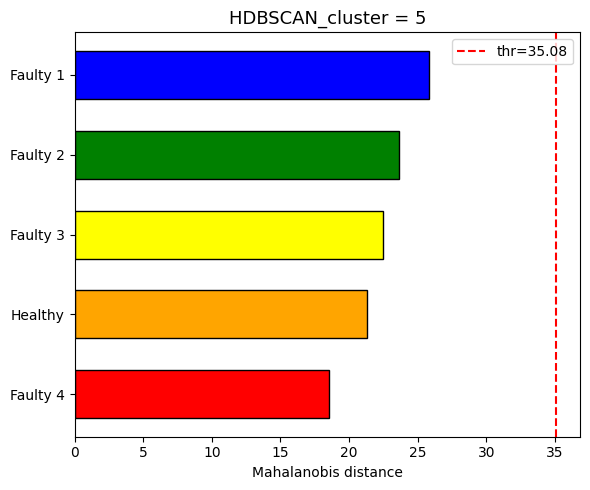

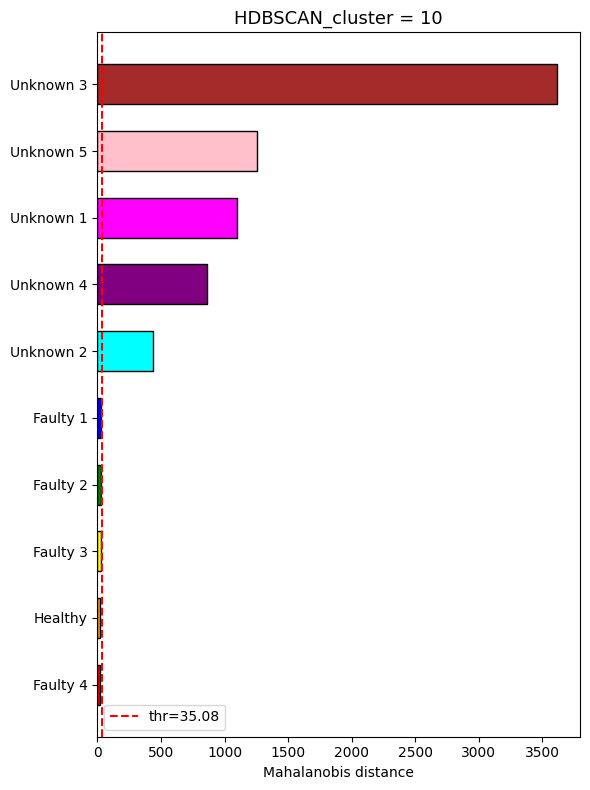

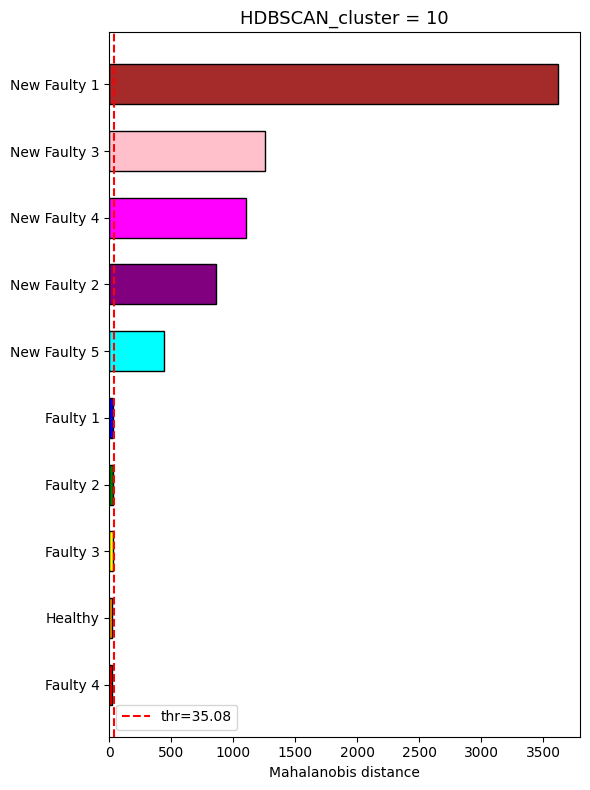

In [28]:
# --------------------------- 主程式 ---------------------------
print("\n=== Loading training data ===")
train_df = load_and_concat(FEATURE_DIR, T_CODE, RPM, LABEL_ORDER)
label_map = {v: i for i, v in enumerate(LABEL_ORDER)}
train_df["label"] = train_df["screws"].map(label_map)
X = train_df.drop(["screws", "label"], axis=1).values
y = train_df["label"].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = RobustScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)
cnn = load_model(MODEL_PATH, compile=False)
feat_model = Model(inputs=cnn.input, outputs=Flatten()(cnn.get_layer("max_pooling1d").output))
X_tr_f = feat_model.predict(X_tr_s.reshape(-1, X_tr_s.shape[1], 1), verbose=0)
X_te_f = feat_model.predict(X_te_s.reshape(-1, X_te_s.shape[1], 1), verbose=0)

for mcs in MIN_CLUSTER_SIZES:
    X_filt, y_filt = fit_hdbscan_inliers(X_tr_f, y_tr, mcs)
    for conf in CONF_LEVELS:
        MU, INV, THR = mahalanobis_stats(X_filt, conf)
        print("\n==============================")
        print(f"▶ mcs={mcs} | conf={conf} | thr={THR:.2f}")
        print("==============================")
        validate_test_set(X_te_f, y_te, mcs, MU, INV, THR)
        for batch in UNKNOWN_BATCHES:
            evaluate_unknown_batch(batch, mcs, MU, INV, THR)
        for batch in UNKNOWN_BATCHES:
            evaluate_unknown_batch2(batch, mcs, MU, INV, THR)